In [246]:
import numpy as np

def make_web(n,k,kmin=0):
    #den her funktion laver et helt random netværk af n sider, hvor hver side har mellem kmin og k links til andre sider.
    

    # Input: n og k er ikke-negative heltal
    # Output: web er en dictionary med n nøgler.
    # Værdien af hver nøgle er en mængde, der er en delmængde af nøglerne.
    
    assert(k < n), "k skal være mindre end n (da man ikke kan linke til sig selv)"
    assert(kmin <= k), "kmin skal være mindre end eller lig med k"
    keys = [i for i in range(n)]# laver en liste fra [0, 1, 2, ..., n-1]
    web = dict()
    for j in keys:
        #for hver hjemmeside finder vi hvor mange hjemmesider den skal linke til (numlinks) og derefter vælger vi hvilke hjemmesider den skal linke til (web[j])
        numlinks = np.random.randint(kmin,k) # generér et tilfældigt tal mellem kmin og k
        web[j] = set() # starter med en tom mængde for hver hjemmeside
        links = []
        for _ in range(numlinks): # nu vælger vi numlinks tilfældige hjemmesider at linke til
            link = np.random.choice(keys) # vælg en tilfældig hjemmeside fra keys
            if link != j: # sørg for at hjemmesiden ikke linker til sig selv
                links.append(int(link)) # tilføj den valgte hjemmeside til links-listen
        web[j] = set(links) # konverter links-listen til en mængde og tildel den til web[j]
    return web

In [247]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(web):
    
    # Input: netværk som dictionary
    # Output: Netværk visualiseret som graf

    G = nx.DiGraph()
    for node, links in web.items():
        G.add_node(node)
        for link in links:
            G.add_edge(node, link)

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', font_size=8, arrows=True)

    # INDSÆT KODE HER

    plt.show()

In [248]:
#opgave 9
def surf_step(web, startpage):
    
    # Input: Et netværk som dictionary og en start side
    # Output: Sandsynlighedsfordeling som dictionary for næste hjemmeside
    
    distribution=dict() # laver en tom dictionary til at gemme sandsynlighedsfordelingen

    for page, links in web.items(): # for hver hjemmeside og dens links i web-dictionaryen
        if links == set(): # hvis hjemmesiden ikke har nogen links, så skal den have en ligelig fordeling over alle sider
            distribution[page] = [1/len(web) for i in range(len(web))] # fordel sandsynligheden ligeligt over alle sider fx laver den [0, 0, 0, 0, 0] -> [1/5, 1/5, 1/5, 1/5, 1/5]
        else: # hvis hjemmesiden har links, så skal den fordele sandsynligheden ligeligt over de sider den linker til
            distribution[page] = [0 for i in range(len(web))] # starter med at lave [0, 0, 0, 0, 0] for hver hjemmeside
            for link in links:
                distribution[page][link] += 1/len(links) # her taget den fx [0, 1, 0, 1, 0] og laver den til [0, 1/2, 0, 1/2, 0] hvis der er 2 links

    
    return distribution[startpage] # returner sandsynlighedsfordelingen for den startside vi har valgt

In [249]:
#opgave 10
def random_surf(web, n):

    # Input: Et netværk som dictionary og antallet af skridt i random surf simuleringen
    # Output: PageRank-værdier for hver side som en dictionary
    ranking=dict()
    starts = [i for i in web.keys()] # en liste over alle hjemmesider
    start_page = np.random.choice(starts) # vælg en random hjemmeside at starte på
    for i in range(n):
        distribution = surf_step(web, start_page) # start med at find sandsynlighedsfordelingen for den startside vi har valgt
        indices = np.arange(len(distribution))
        start_page = np.random.choice(indices, p=distribution) # vælg en ny startside baseret på sandsynlighedsfordelingen
        if start_page not in ranking.keys(): # hver gang vi lander på en hjemmeside, så tæller vi det i ranking-dictionaryen
            ranking[int(start_page)] = 1
        else:
            ranking[int(start_page)] +=1
    for i in ranking.keys():
        ranking[i] = ranking[i]/n # til sidst dividerer vi hver tælling i ranking-dictionaryen med n for at få en sandsynlighedsfordeling over hvor ofte vi lander på hver hjemmeside
    
    # INDSÆT KODE HER

    return ranking

In [250]:
web = make_web(10, 6)

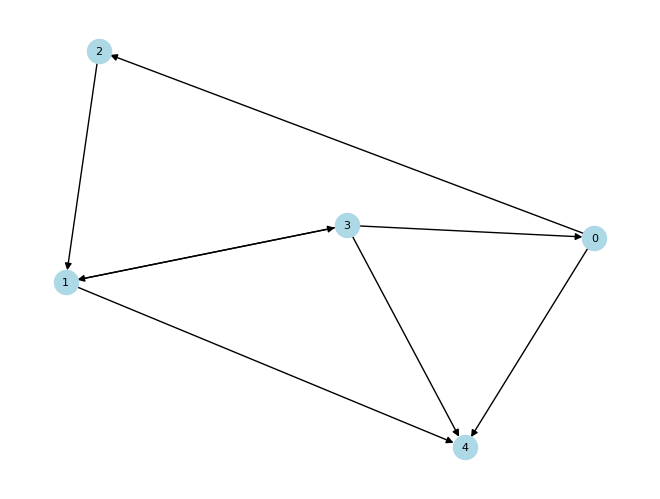

In [251]:
visualize_graph(W1)

# opgave 11

In [252]:
def surf_step_damp(web, start_page, d):
    
    # Input: Et netværk som dictionary, en start side og en dæmpningsfaktor
    # Output: Sandsynlighedsfordeling som dictionary for næste hjemmeside
    
    distribution=dict()

    distribution=dict() # laver en tom dictionary til at gemme sandsynlighedsfordelingen

    for page, links in web.items(): # for hver hjemmeside og dens links i web-dictionaryen
        if links == set(): # hvis hjemmesiden ikke har nogen links, så skal den have en ligelig fordeling over alle sider
            distribution[page] = [1/len(web) for i in range(len(web))] # fordel sandsynligheden ligeligt over alle sider fx laver den [0, 0, 0, 0, 0] -> [1/5, 1/5, 1/5, 1/5, 1/5]
        else: # hvis hjemmesiden har links, så skal den fordele sandsynligheden ligeligt over de sider den linker til
            distribution[page] = [0 for i in range(len(web))] # starter med at lave [0, 0, 0, 0, 0] for hver hjemmeside
            for link in links:
                distribution[page][link] += 1/len(links) # her taget den fx [0, 1, 0, 1, 0] og laver den til [0, 1/2, 0, 1/2, 0] hvis der er 2 links


    # INDSÆT KODE HER

    uniform = [1/len(web) for i in range(len(web))]
    sandsynlighed = [d, 1-d]
    indices = [1, 2]
    number = np.random.choice(indices, p=sandsynlighed)
    if number == 1:
        test = distribution[start_page]
    if number == 2:
        test = uniform
    return test

In [253]:
def random_surf_damp(web, n, d):

    # Input: Et netværk som dictionary, antallet af skridt i random surf simuleringen og en dæmpningsfaktor
    # Output: PageRank-værdier for hver side som en dictionary

        # Input: Et netværk som dictionary og antallet af skridt i random surf simuleringen
    # Output: PageRank-værdier for hver side som en dictionary
    ranking=dict()
    starts = [i for i in web.keys()] # en liste over alle hjemmesider
    start_page = np.random.choice(starts) # vælg en random hjemmeside at starte på
    for i in range(n):
        distribution = surf_step_damp(web, start_page, 0.85) # start med at find sandsynlighedsfordelingen for den startside vi har valgt
        indices = np.arange(len(distribution))
        start_page = np.random.choice(indices, p=distribution) # vælg en ny startside baseret på sandsynlighedsfordelingen
        if start_page not in ranking.keys(): # hver gang vi lander på en hjemmeside, så tæller vi det i ranking-dictionaryen
            ranking[int(start_page)] = 1
        else:
            ranking[int(start_page)] +=1
    for i in ranking.keys():
        ranking[i] = ranking[i]/n # til sidst dividerer vi hver tælling i ranking-dictionaryen med n for at få en sandsynlighedsfordeling over hvor ofte vi lander på hver hjemmeside
    



 
    # INDSÆT KODE HER

    return ranking

In [254]:
W2 = {
    0: {1},
    1: {2},
    2: {0},
    3: {4},
    4: {5},
    5: {3}}


W1 = {
    0: {2, 4},
    1: {3, 4},
    2: {1},
    3: {0, 1, 4},
    4: set()}

# opgave 13

In [255]:
for n in range(1000, 1010, 1):
    print(random_surf(W1, n))

{3: 0.183, 4: 0.335, 1: 0.246, 2: 0.12, 0: 0.116}
{4: 0.34565434565434566, 1: 0.22777222777222778, 2: 0.11988011988011989, 3: 0.17082917082917082, 0: 0.13586413586413587}
{1: 0.2375249500998004, 3: 0.2025948103792415, 4: 0.313373253493014, 2: 0.1157684630738523, 0: 0.13073852295409183}
{3: 0.18743768693918245, 1: 0.2612163509471585, 4: 0.3150548354935194, 2: 0.11665004985044865, 0: 0.11964107676969092}
{3: 0.20219123505976094, 1: 0.25199203187250996, 4: 0.3107569721115538, 2: 0.11155378486055777, 0: 0.12350597609561753}
{3: 0.19502487562189055, 4: 0.31343283582089554, 0: 0.14228855721393036, 2: 0.11243781094527364, 1: 0.23681592039800994}
{4: 0.31312127236580517, 2: 0.11232604373757456, 1: 0.24652087475149106, 3: 0.19980119284294234, 0: 0.12823061630218688}
{3: 0.19761668321747766, 0: 0.1320754716981132, 2: 0.10724925521350546, 1: 0.24528301886792453, 4: 0.31777557100297915}
{0: 0.11805555555555555, 4: 0.31547619047619047, 2: 0.1130952380952381, 1: 0.2509920634920635, 3: 0.202380952380

In [256]:
for n in range(1000, 1010, 1):
    print(random_surf(W2, n))

{3: 0.334, 4: 0.333, 5: 0.333}
{5: 0.3336663336663337, 3: 0.3336663336663337, 4: 0.33266733266733267}
{0: 0.3333333333333333, 1: 0.3333333333333333, 2: 0.3333333333333333}
{2: 0.3339980059820538, 0: 0.33300099700897307, 1: 0.33300099700897307}
{4: 0.3336653386454183, 5: 0.3336653386454183, 3: 0.33266932270916333}
{1: 0.3333333333333333, 2: 0.3333333333333333, 0: 0.3333333333333333}
{0: 0.33399602385685884, 1: 0.33300198807157055, 2: 0.33300198807157055}
{0: 0.3336643495531281, 1: 0.3336643495531281, 2: 0.3326713008937438}
{0: 0.3333333333333333, 1: 0.3333333333333333, 2: 0.3333333333333333}
{0: 0.333994053518335, 1: 0.3330029732408325, 2: 0.3330029732408325}


In [257]:
for n in range(1000, 1010, 1):
    print(random_surf_damp(W1, n, 0.85))

{4: 0.305, 2: 0.141, 1: 0.234, 3: 0.182, 0: 0.138}
{0: 0.14185814185814186, 4: 0.2777222777222777, 3: 0.1938061938061938, 1: 0.24075924075924077, 2: 0.14585414585414586}
{2: 0.1277445109780439, 1: 0.24550898203592814, 4: 0.3003992015968064, 3: 0.18862275449101795, 0: 0.1377245508982036}
{3: 0.1744765702891326, 1: 0.2572283150548355, 4: 0.3000997008973081, 2: 0.1415752741774676, 0: 0.12662013958125623}
{1: 0.25199203187250996, 3: 0.18824701195219123, 0: 0.13346613545816732, 4: 0.29780876494023906, 2: 0.12848605577689243}
{1: 0.25771144278606967, 4: 0.2885572139303483, 3: 0.1900497512437811, 0: 0.1253731343283582, 2: 0.1383084577114428}
{1: 0.23856858846918488, 4: 0.30318091451292245, 0: 0.14512922465208747, 3: 0.18290258449304175, 2: 0.13021868787276342}
{4: 0.29493545183714004, 1: 0.2512413108242304, 3: 0.1916583912611718, 0: 0.12512413108242304, 2: 0.13704071499503476}
{3: 0.1884920634920635, 4: 0.28869047619047616, 0: 0.12896825396825398, 2: 0.15476190476190477, 1: 0.2390873015873016

In [258]:
for n in range(1000, 1010, 1):
    print(random_surf_damp(W2, n, 0.85))

{5: 0.145, 3: 0.142, 4: 0.143, 1: 0.189, 2: 0.192, 0: 0.189}
{3: 0.18581418581418582, 4: 0.1878121878121878, 5: 0.1878121878121878, 1: 0.14585414585414586, 2: 0.14585414585414586, 0: 0.14685314685314685}
{0: 0.18862275449101795, 1: 0.19560878243512975, 2: 0.18962075848303392, 5: 0.14570858283433133, 3: 0.13972055888223553, 4: 0.1407185628742515}
{2: 0.15653040877367896, 0: 0.16650049850448653, 1: 0.15653040877367896, 3: 0.17248255234297108, 4: 0.17347956131605186, 5: 0.1744765702891326}
{2: 0.17828685258964144, 0: 0.17629482071713148, 1: 0.17231075697211157, 4: 0.15637450199203187, 5: 0.1553784860557769, 3: 0.16135458167330677}
{5: 0.1472636815920398, 3: 0.15323383084577114, 4: 0.14427860696517414, 2: 0.18109452736318407, 0: 0.18208955223880596, 1: 0.19203980099502488}
{2: 0.16998011928429424, 0: 0.1679920477137177, 1: 0.16699801192842942, 4: 0.1709741550695825, 5: 0.16401590457256462, 3: 0.16003976143141152}
{3: 0.17676266137040714, 4: 0.18768619662363456, 0: 0.15690168818272096, 5: 0

# opgave 15

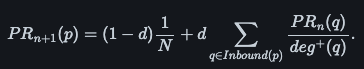

In [259]:
#en ad gangen
def rank_update(web, PageRanks, page, d):
        N = len(web)
        """
        Opdaterer værdien af PageRank for en side baseret på den rekursive formel
        Sider uden udgående links (sinks) behandles som om de linker til alle sider på nettet.

        Input: 
            web og PageRanks er dictionaries som i outputtet fra "make_web" og "random_surf",
            page er nøglen til den side, hvis rank vi ønsker at opdatere, og
            d er dampingfaktoren.
        Output: 
            PageRank opdateres i henhold til ovenstående formel,
            og denne funktion returnerer et float "increment", den (absolutte) forskel
            mellem den tidligere værdi og den opdaterede værdi af PR(p).
        """
        inbound_sum = 0
        for q, p in web.items():
            #print(q, p)
            if page in p:
                inbound_sum += PageRanks[q]/len(p)
            if p == set():
                 inbound_sum += PageRanks[q]/(len(web))
        
        new_rank = (1-d)*(1/N) + (d*(inbound_sum))
        change = abs(PageRanks[page] - new_rank)
        PageRanks[page] = new_rank
        return change

In [260]:
#en ad gangen
def recursive_PageRank(web, stopvalue=0.0001, max_iterations=200, d=0.85):
    """
    Implementerer den rekursive version af PageRank-algoritmen ved først at oprette
    en PageRank på 1/N til alle sider (hvor N er det samlede antal sider)
    og derefter anvende "rank_update" gentagne gange, indtil en af de to stopbetingelser
    er opnået:
    stopbetingelse 1: den maksimale ændring fra trin n til trin (n+1) over alle PageRank
    er mindre end stopværdien,
    Stopbetingelse 2: antallet af iterationer har nået "max_iterations".

    Input: web er et dictionary som i outputtet af "make_web", d er dæmpningen,
    stopvalue er et positivt float, max_iterations er et positivt heltal.
    """
    PageRanks = dict()
    for i in range(len(web)):
        PageRanks[i] = 1/len(web)
    latest_increment = dict()
    for iteration in range(max_iterations):
        stop = 0 
        for page in web.keys():
            change = rank_update(web, PageRanks, page, d)
            #print(change)
            if change < stopvalue:
                stop += 1
                #print(stop)
        if stop == len(web.keys()):
            return PageRanks, iteration


    return PageRanks, iteration

In [261]:
#alle på samme tid
def rank_update2(web, PageRanks, page, d):
        N = len(web)
        """
        Opdaterer værdien af PageRank for en side baseret på den rekursive formel
        Sider uden udgående links (sinks) behandles som om de linker til alle sider på nettet.

        Input: 
            web og PageRanks er dictionaries som i outputtet fra "make_web" og "random_surf",
            page er nøglen til den side, hvis rank vi ønsker at opdatere, og
            d er dampingfaktoren.
        Output: 
            PageRank opdateres i henhold til ovenstående formel,
            og denne funktion returnerer et float "increment", den (absolutte) forskel
            mellem den tidligere værdi og den opdaterede værdi af PR(p).
        """
        inbound_sum = 0
        for q, p in web.items():
            #print(q, p)
            if page in p:
                inbound_sum += PageRanks[q]/len(p)
            if p == set():
                 inbound_sum += PageRanks[q]/(len(web))
        
        new_rank = (1-d)*(1/N) + (d*(inbound_sum))
        change = abs(PageRanks[page] - new_rank)
        #PageRanks[page] = new_rank
        return new_rank

In [262]:
#alle på samme tid
def recursive_PageRank2(web, stopvalue=0.0001, max_iterations=200, d=0.85):
    """
    Implementerer den rekursive version af PageRank-algoritmen ved først at oprette
    en PageRank på 1/N til alle sider (hvor N er det samlede antal sider)
    og derefter anvende "rank_update" gentagne gange, indtil en af de to stopbetingelser
    er opnået:
    stopbetingelse 1: den maksimale ændring fra trin n til trin (n+1) over alle PageRank
    er mindre end stopværdien,
    Stopbetingelse 2: antallet af iterationer har nået "max_iterations".

    Input: web er et dictionary som i outputtet af "make_web", d er dæmpningen,
    stopvalue er et positivt float, max_iterations er et positivt heltal.
    """
    PageRanks = dict()
    for i in range(len(web)):
        PageRanks[i] = 1/len(web)
    for iteration in range(max_iterations):
        new_rank = {}
        for page in web.keys():
            new_rank[page] = rank_update2(web, PageRanks, page, d)
            #print(max(list(change.items()))[1])
        max_change = max(abs(new_rank[p] - PageRanks[p]) for p in web.keys())
        PageRanks = new_rank
        if max_change < stopvalue:
            return PageRanks, iteration


    return PageRanks, iteration

In [263]:
recursive_PageRank2(W1), recursive_PageRank(W1)

(({0: 0.1329244916791924,
   1: 0.24910563421313253,
   2: 0.1366725097485432,
   3: 0.18604928854533567,
   4: 0.29524807581379636},
  10),
 ({0: 0.1327714381200655,
   1: 0.24880659980250253,
   2: 0.1365540842634364,
   3: 0.18586902797847216,
   4: 0.29495978044006715},
  13))

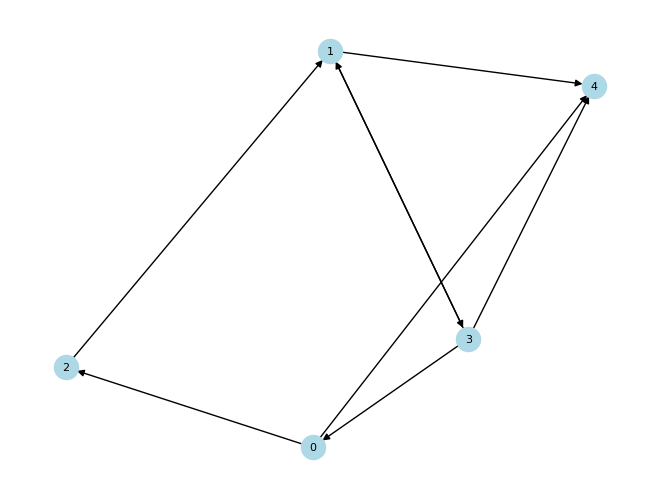

In [264]:
visualize_graph(W1)